# Библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

## 8.5 Столбиковые\Линейчатые диаграммы: вертикальные и горизонтальные

- Продукт - категории трех продуктов A, B и C
- Сегмент - данные о том, клиенты из какого сегмента приобретали такое кок-во товара в месяце (B2C массовый рынок, B2B  предприятия,  B2G государственные компании и службы)
- Продажи - количество товара.

In [2]:
z = pd.read_excel('./data/Lecture8.1.xlsx')

In [3]:
z

,Дата,Продукт,Сегмент,Продажи
0,2023-01-31,А,B2C,24029
1,2023-02-28,А,B2C,33691
2,2023-03-31,А,B2C,14009
3,2023-04-30,А,B2C,22871
4,2023-05-31,А,B2C,22438
...,...,...,...,...
103,2023-08-31,C,B2G,23401
104,2023-09-30,C,B2G,18145
105,2023-10-31,C,B2G,18553
106,2023-11-30,C,B2G,31082


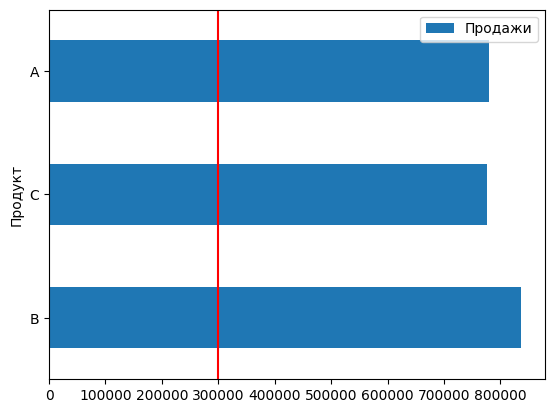

In [4]:
(z
 .groupby('Продукт', as_index=False)['Продажи']
 .sum()
 .plot(kind='barh', x='Продукт', y='Продажи'
      ).axvline(300000, color='red'))

## 8.6 Разбор и управление элементами диаграмм

(np.float64(-0.5), np.float64(2.5), np.float64(0.0), np.float64(850000.0))

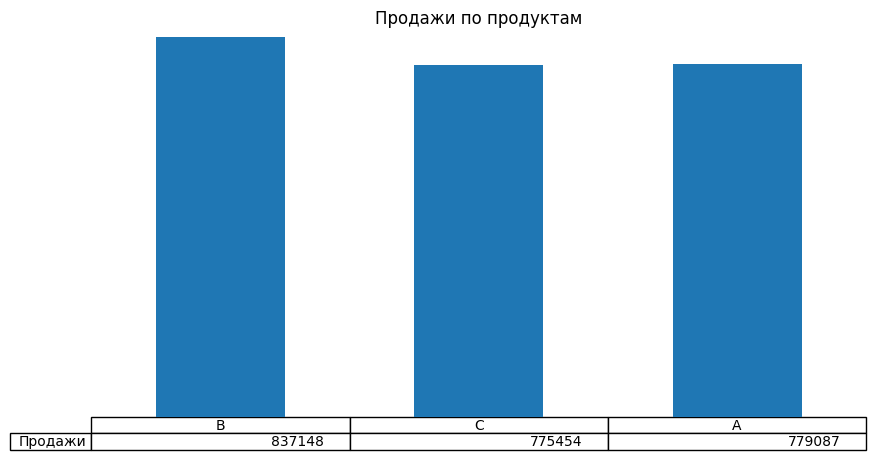

In [5]:
(z
    .groupby('Продукт', as_index=False)['Продажи']
    .sum()
    .plot(kind='bar', x='Продукт', y='Продажи',
         figsize=(10,5),
         title='Продажи по продуктам',
         legend=False,
          xlabel='Product',
          ylabel='Sales',
          ylim=(0,850000),
          yticks=[200000,400000,600000,800000],
          grid = True,
          fontsize=10,
          table=True
         ).axis('off')
)

## 8.7 Цветовое форматирование визуальных элементов

(np.float64(-0.5), np.float64(2.5), np.float64(0.0), np.float64(850000.0))

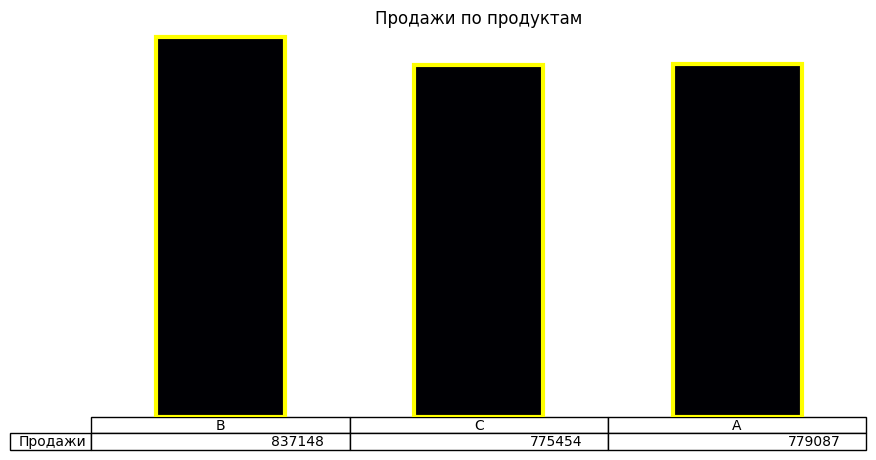

In [6]:
z.groupby('Продукт',as_index=False)['Продажи'].sum().plot(kind='bar', x='Продукт', y='Продажи',
                                                         figsize=(10,5),
                                                         title='Продажи по продуктам',
                                                         legend=False,
                                                          xlabel='Product',
                                                          ylabel='Sales',
                                                          ylim=(0,850000),
                                                          yticks=[200000,400000,600000,800000],
                                                          grid = True,
                                                          fontsize=20,
                                                          table=True,
                                                          colormap='magma',
                                                          edgecolor='yellow',
                                                          lw=3
                                                         ).axis('off')

## 8.8 Группировка с распаковкой индекса: метод .groupby() с .unstack()

In [7]:
g = z.groupby(['Продукт','Сегмент'])['Продажи'].sum()

<Axes: xlabel='Продукт,Сегмент'>

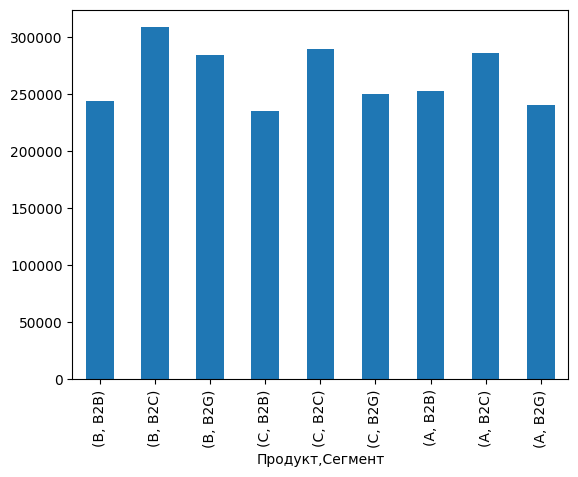

In [8]:
g.plot.bar()

In [9]:
g.unstack()

Сегмент,B2B,B2C,B2G
Продукт,,,
B,243952,308789,284407
C,235706,289756,249992
А,252724,286058,240305


<Axes: xlabel='Продукт'>

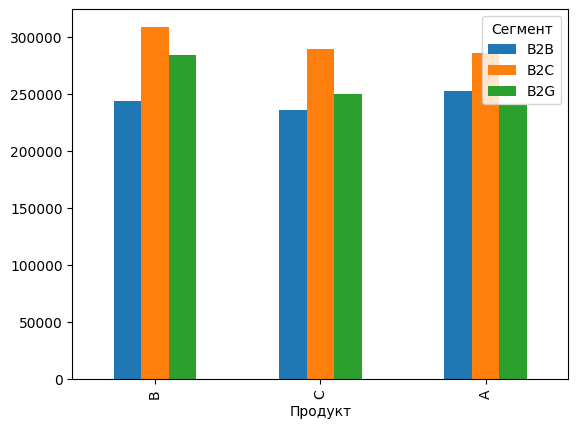

In [10]:
g.unstack().plot.bar()

## 8.9 Столбцы на разные диаграммы (subplots)

array([[<Axes: title={'center': 'B2B'}, xlabel='Продукт'>,
        <Axes: title={'center': 'B2C'}, xlabel='Продукт'>],
       [<Axes: title={'center': 'B2G'}, xlabel='Продукт'>,
        <Axes: xlabel='Продукт'>]], dtype=object)

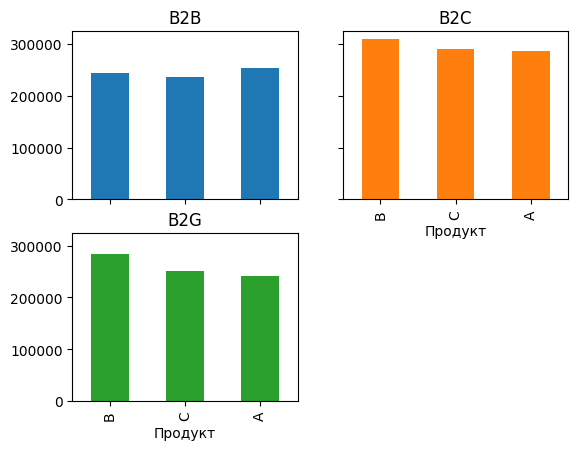

In [11]:
(g
    .unstack()
    .plot.bar(
        subplots=True,
        legend=False,
        sharey=True,
        layout=(2,2)
    )
)

In [12]:
## 

<Axes: xlabel='Продукт'>

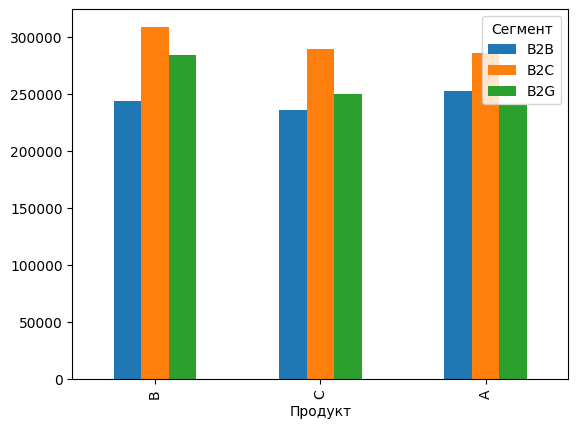

In [13]:
g.unstack().plot.bar()

## 8.10 Столбиковые диаграммы: с группировкой и с наложением

<Axes: xlabel='Продукт'>

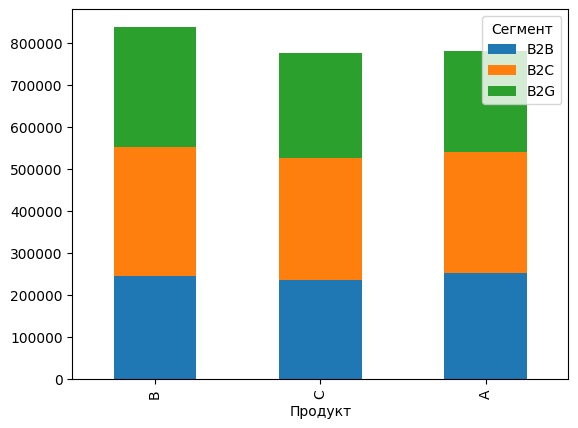

In [14]:
g.unstack().plot.bar(stacked=True)

## 8.11 Погрешности\Коридор прогноза на диаграммах

In [15]:
p = z.groupby('Дата', as_index=False)['Продажи'].sum()

In [16]:
p['yerror'] = p['Продажи'] * 0.07

In [17]:
p.head(3)

,Дата,Продажи,yerror
0,2023-01-31,188046,13163.22
1,2023-02-28,181880,12731.60
2,2023-03-31,211977,14838.39


<Axes: xlabel='Дата'>

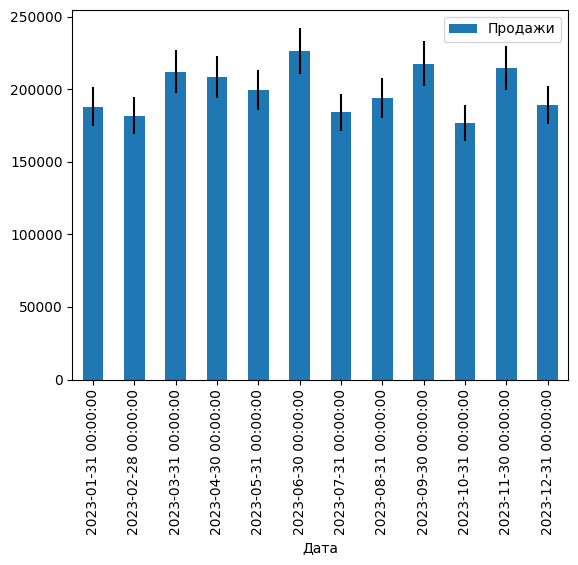

In [18]:
p.plot(kind='bar', x='Дата', y='Продажи', yerr='yerror')

## 8.12 График

C:\Users\ilyao\AppData\Roaming\uv\tools\jupyterlab\Lib\site-packages\matplotlib\transforms.py:2651: RuntimeWarning: divide by zero encountered in scalar divide
  x_scale = 1.0 / inw
C:\Users\ilyao\AppData\Roaming\uv\tools\jupyterlab\Lib\site-packages\matplotlib\transforms.py:2653: RuntimeWarning: invalid value encountered in scalar multiply
  self._mtx = np.array([[x_scale,     0.0, -inl*x_scale],
C:\Users\ilyao\AppData\Roaming\uv\tools\jupyterlab\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


<Axes: xlabel='Дата'>

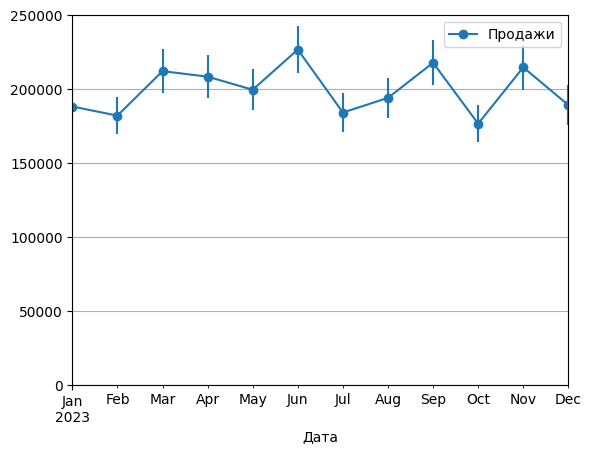

In [19]:
p.plot(kind='line', x='Дата', y='Продажи', yerr='yerror', ylim=(0,250000), marker='o', grid=True)

## 8.15 График\диаграмма с областями

In [20]:
p['F'] = p['Продажи'] * 0.9

In [24]:
p.head(n=3)

,Дата,Продажи,yerror,F
0,2023-01-31,188046,13163.22,169241.4
1,2023-02-28,181880,12731.60,163692.0
2,2023-03-31,211977,14838.39,190779.3


<Axes: xlabel='Дата'>

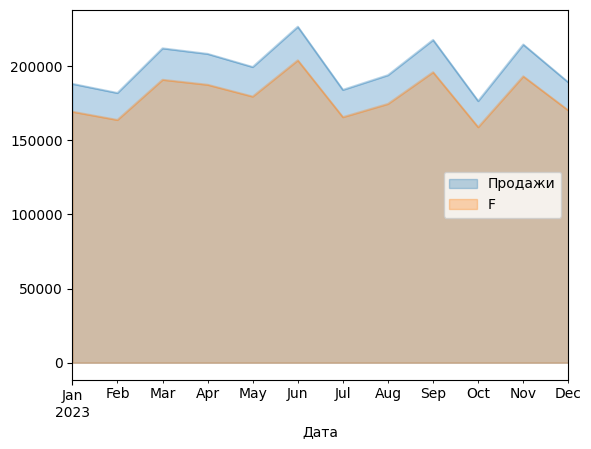

In [22]:
p.plot.area(x='Дата', y=['Продажи', 'F'], stacked=False, alpha=0.3)

## 8.16 Круговые диаграммы

array([<Axes: ylabel='B2B'>, <Axes: ylabel='B2C'>, <Axes: ylabel='B2G'>],
      dtype=object)

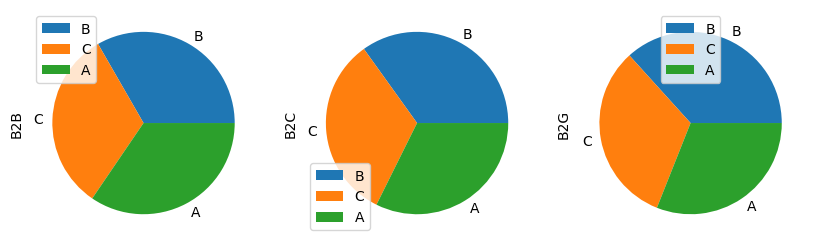

In [26]:
g.unstack().plot.pie(subplots = True, figsize = (10,10))

# end